In [1]:
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import RepeatedKFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
import matplotlib.pyplot as plt


In [2]:
df1 = pd.read_csv('cleaned_with_text.csv')
df2 = pd.read_csv('cleaned_without.csv')
train_ratio = 0.70
test_ratio = 0.15
validation_ratio = 0.15

In [3]:
X = df2[['sqft','stories','beds','baths','baths_full','baths_full_calc','garage','year_built','type_condos','type_farm','type_multi_family','type_single_family','type_townhome']]
y = df2[['listPrice']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=(validation_ratio/(1-test_ratio)), random_state=42)

In [4]:
# Model 1: Default
pipeline = Pipeline([
                    ('imputer',SimpleImputer(strategy='mean')),
                    ('regressor', Ridge(alpha=1.0))
                    ])


pipeline.fit(X_train,y_train)
y_pred_test = pipeline.predict(X_test)
y_pred_val  = pipeline.predict(X_val)
y_pred_train = pipeline.predict(X_train)

val_pred_default = pipeline.predict(X_val)
test_pred_default = pipeline.predict(X_test)

print("── Default ──")
print("Val R²:  ", round(r2_score(y_val, val_pred_default), 4))
print("Val RMSE:", round(np.sqrt(mean_squared_error(y_val, val_pred_default)), 4))
print("Val MAE: ", round(mean_absolute_error(y_val, val_pred_default), 4))
print("Test R²:  ", round(r2_score(y_test, test_pred_default), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, test_pred_default)), 4))
print("Test MAE: ", round(mean_absolute_error(y_test, test_pred_default), 4))

── Default ──
Val R²:   0.5724
Val RMSE: 0.3975
Val MAE:  0.2802
Test R²:   0.4524
Test RMSE: 0.4656
Test MAE:  0.3046


In [9]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100, log=True)
    imputer_strategy = trial.suggest_categorical('imputer_strategy', 
                                                  ['mean', 'median', 'most_frequent'])
    
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy=imputer_strategy)),
        ('regressor', Ridge(alpha=alpha))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred_val = pipeline.predict(X_val)
    
    return np.sqrt(mean_squared_error(y_val, y_pred_val))  # minimise RMSE on val set

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=2000)

print(f"Best alpha:    {study.best_trial.params['alpha']:.4f}")
print(f"Best strategy: {study.best_trial.params['imputer_strategy']}")
print(f"Best val RMSE: {study.best_trial.value:.4f}")

[I 2026-03-27 16:52:55,193] A new study created in memory with name: no-name-e224fb3b-cc98-45bb-9740-85089e3ca9af
[I 2026-03-27 16:52:55,210] Trial 0 finished with value: 0.3973368653569317 and parameters: {'alpha': 0.06296245929841225, 'imputer_strategy': 'mean'}. Best is trial 0 with value: 0.3973368653569317.
[I 2026-03-27 16:52:55,216] Trial 1 finished with value: 0.40375243131715216 and parameters: {'alpha': 28.17098511206186, 'imputer_strategy': 'mean'}. Best is trial 0 with value: 0.3973368653569317.
[I 2026-03-27 16:52:55,220] Trial 2 finished with value: 0.40359902285511123 and parameters: {'alpha': 27.361833053088755, 'imputer_strategy': 'mean'}. Best is trial 0 with value: 0.3973368653569317.
[I 2026-03-27 16:52:55,223] Trial 3 finished with value: 0.397359432341953 and parameters: {'alpha': 0.1832326236216849, 'imputer_strategy': 'mean'}. Best is trial 0 with value: 0.3973368653569317.
[I 2026-03-27 16:52:55,231] Trial 4 finished with value: 0.40645443826506505 and paramete

Best alpha:    0.0010
Best strategy: mean
Best val RMSE: 0.3973


In [10]:
# Model 2: Tuned

best_alpha    = study.best_trial.params['alpha']
best_strategy = study.best_trial.params['imputer_strategy']

second_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy=best_strategy)),
    ('regressor', Ridge(alpha=best_alpha))
])

second_pipeline.fit(X_train, y_train)

y_pred_test = second_pipeline.predict(X_test)
y_pred_val  = second_pipeline.predict(X_val)
y_pred_train = second_pipeline.predict(X_train)

val_pred_default = second_pipeline.predict(X_val)
test_pred_default = second_pipeline.predict(X_test)

print("── Default ──")
print("Val R²:  ", round(r2_score(y_val, val_pred_default), 4))
print("Val RMSE:", round(np.sqrt(mean_squared_error(y_val, val_pred_default)), 4))
print("Val MAE: ", round(mean_absolute_error(y_val, val_pred_default), 4))
print("-----")
print("Test R²:  ", round(r2_score(y_test, test_pred_default), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, test_pred_default)), 4))
print("Test MAE: ", round(mean_absolute_error(y_test, test_pred_default), 4))
print("Test MSE:", round(mean_squared_error(y_test, test_pred_default), 4))

── Default ──
Val R²:   0.5728
Val RMSE: 0.3973
Val MAE:  0.2802
-----
Test R²:   0.4507
Test RMSE: 0.4663
Test MAE:  0.305
Test MSE: 0.2175


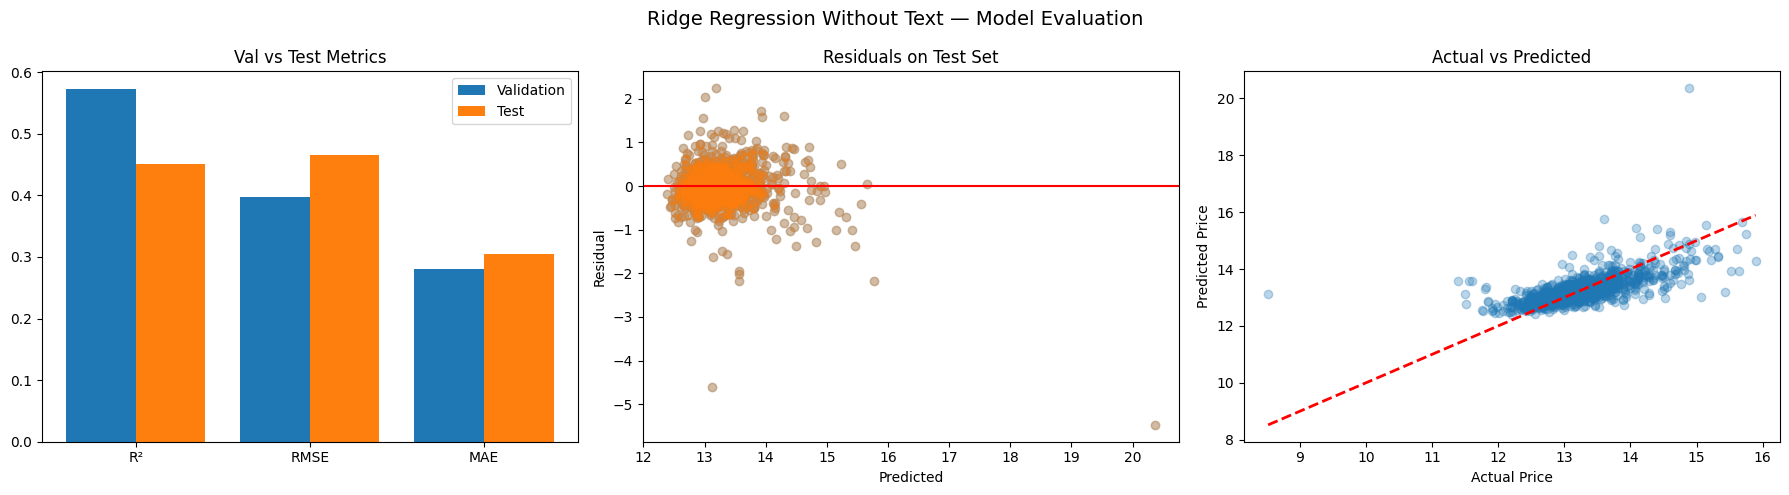

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ridge Regression Without Text — Model Evaluation', fontsize=14)

# Plot 1 — Val vs Test metrics
metrics = ['R²', 'RMSE', 'MAE']
val_scores = [r2_score(y_val, y_pred_val),
              np.sqrt(mean_squared_error(y_val, y_pred_val)),
              mean_absolute_error(y_val, y_pred_val)]
test_scores = [r2_score(y_test, y_pred_test),
               np.sqrt(mean_squared_error(y_test, y_pred_test)),
               mean_absolute_error(y_test, y_pred_test)]

x = np.arange(len(metrics))


# Flatten both to 1D arrays before plotting
y_test_flat = np.array(y_test).flatten()
y_val_flat  = np.array(y_val).flatten()
y_pred_test_flat = np.array(y_pred_test).flatten()
y_pred_val_flat  = np.array(y_pred_val).flatten()

# Then use the flat versions throughout
val_scores = [r2_score(y_val_flat, y_pred_val_flat),
              np.sqrt(mean_squared_error(y_val_flat, y_pred_val_flat)),
              mean_absolute_error(y_val_flat, y_pred_val_flat)]

test_scores = [r2_score(y_test_flat, y_pred_test_flat),
               np.sqrt(mean_squared_error(y_test_flat, y_pred_test_flat)),
               mean_absolute_error(y_test_flat, y_pred_test_flat)]

residuals = y_test_flat - y_pred_test_flat

# Rest of your plotting code stays the same, just use the flat versions

axes[0].bar(x - 0.2, val_scores, 0.4, label='Validation')
axes[0].bar(x + 0.2, test_scores, 0.4, label='Test')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title('Val vs Test Metrics')
axes[0].legend()

# Plot 2 — Residuals
axes[1].scatter(y_pred_test_flat, residuals, alpha=0.3)
axes[1].axhline(0, color='red')
axes[1].set_title('Residuals on Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

# Plot 3 — Actual vs Predicted
axes[1].scatter(y_pred_test_flat, residuals, alpha=0.3)
axes[2].scatter(y_test_flat, y_pred_test_flat, alpha=0.3)
axes[2].plot([y_test_flat.min(), y_test_flat.max()],
             [y_test_flat.min(), y_test_flat.max()], 'r--', lw=2)

axes[2].set_title('Actual vs Predicted')
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

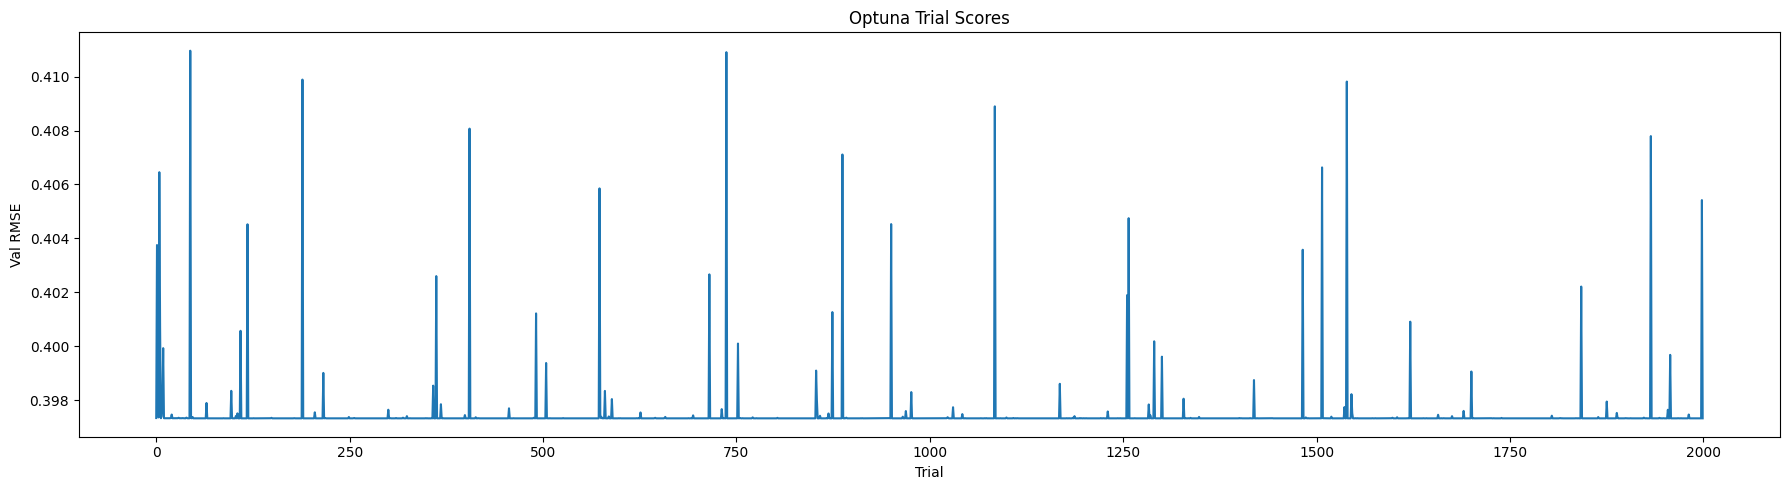

In [16]:
fig, axes = plt.subplots(1, figsize=(18, 5))

# Plot 1 — Optuna trial scores (only if you ran the tuning)
trial_values = [t.value for t in study.trials]
axes.plot(trial_values)
axes.set_title('Optuna Trial Scores')
axes.set_xlabel('Trial')
axes.set_ylabel('Val RMSE')

# Plot 2 — Residuals on test set
#residuals = np.array(y_test) - np.array(y_pred_test)
#axes[1].scatter(y_pred_test_flat, residuals, alpha=0.3)
#axes[1].axhline(0, color='red')
#axes[1].set_title('Residuals on Test Set')
#axes[1].set_xlabel('Predicted Price')
#axes[1].set_ylabel('Residual')


plt.tight_layout()
plt.show()